# Titanic Dataset - Cleaning, EDA and Feature Engineering

## 1. Load and Understand the Dataset

In [1]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2. Data Cleaning

### Handling Missing Values

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df["Age"].median()

28.0

In [7]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [8]:
df["Age"].isnull().sum()

np.int64(0)

In [9]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [10]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [11]:
df["Embarked"].isnull().sum()

np.int64(0)

In [12]:
df["HasCabin"] = df["Cabin"].notnull().astype(int)

In [13]:
df[["Cabin", "HasCabin"]].head()

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0


In [14]:
df.drop("Cabin", axis=1, inplace=True)

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Checking Duplicate Records

In [16]:
df.duplicated().sum()

np.int64(0)

### Outlier Analysis

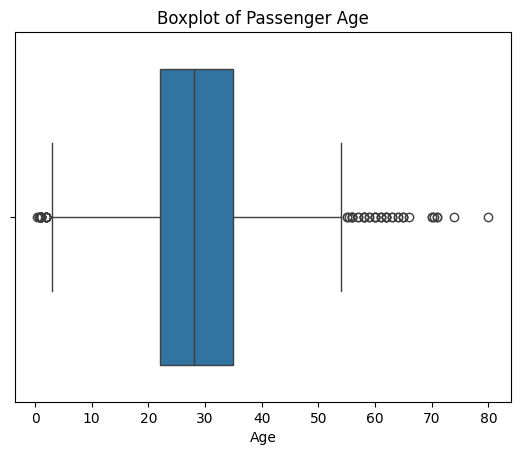

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age contains some potential outliers among older passengers.
# These ages are realistic, so they are retained.
sns.boxplot(x=df["Age"])
plt.title("Boxplot of Passenger Age")
plt.show()

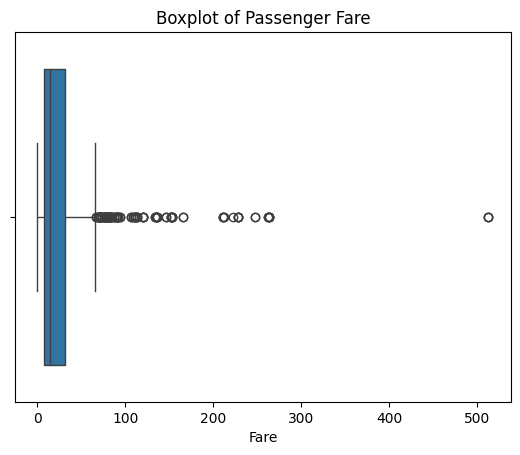

In [18]:
# Fare contains several high-value outliers.
# These values may represent legitimate expensive tickets,
# so they are retained rather than removed.
sns.boxplot(x=df["Fare"])
plt.title("Boxplot of Passenger Fare")
plt.show()

## 3. Exploratory Data Analysis (EDA)

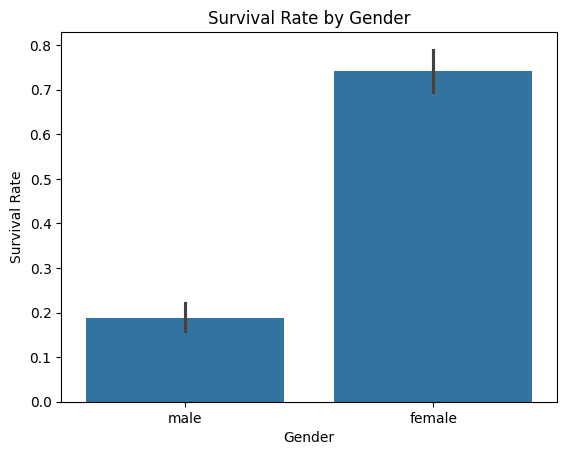

In [19]:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

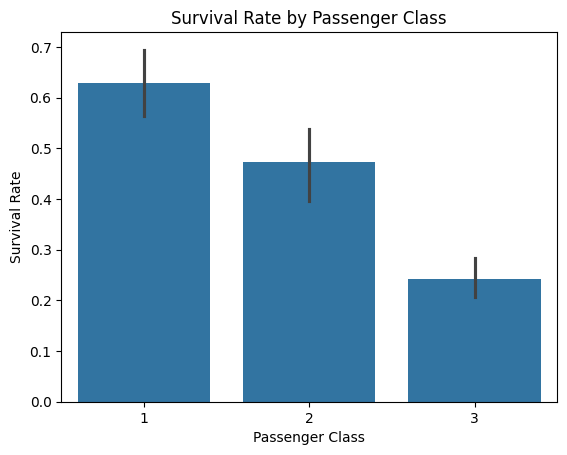

In [20]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

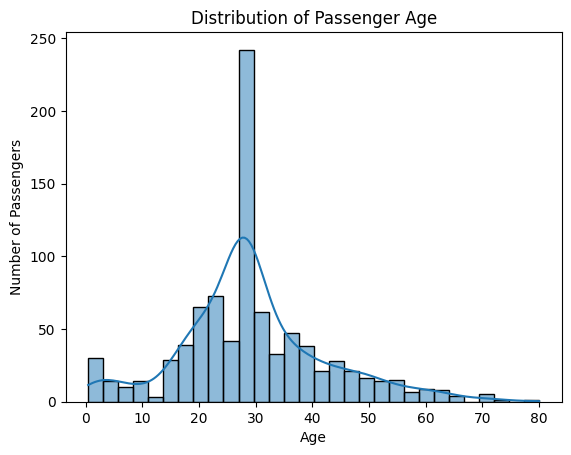

In [21]:
sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

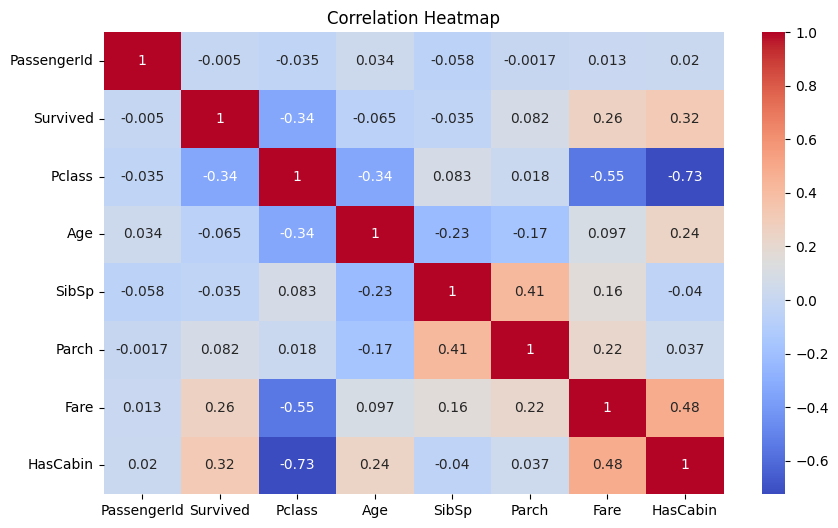

In [22]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 4. Feature Engineering

In [23]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [24]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [25]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [27]:
df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [28]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nEngineered features:")
print(df[["HasCabin", "FamilySize", "IsAlone"]].head())

Dataset shape: (891, 14)

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
FamilySize     0
IsAlone        0
dtype: int64

Duplicate rows: 0

Engineered features:
   HasCabin  FamilySize  IsAlone
0         0           2        0
1         1           2        0
2         0           1        1
3         1           2        0
4         0           1        1


## 5. Key Insights

1. Female passengers had a much higher survival rate (about 74%) compared with male passengers (about 19%).

2. First-class passengers had the highest survival rate (about 63%), while third-class passengers had the lowest survival rate (about 24%).

3. The Age column had 177 missing values, which were filled using the median age of 28. The histogram therefore shows a noticeable concentration around age 28.

4. Fare had several high-value outliers. These values were retained because they may represent valid expensive tickets, especially for higher-class passengers.

5. The correlation analysis showed that passenger class and fare were related to survival. First-class and higher-fare passengers generally had better survival outcomes.